# MILP – Optimasi Q, SS, dan ROP (Bins + Zero-bin + Toggle Missed-Order Penalty)

In [42]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import pulp as pl
import matplotlib.pyplot as plt
from typing import Dict, List
import re, time
from datetime import datetime
from pathlib import Path

RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8')

ENFORCE_SS_TARGET = True
ENFORCE_BUDGET    = True
INCLUDE_SHORTAGE  = True

Q_BINS_COUNT = 50
INCLUDE_ZERO_BIN = False
USE_MISSED_ORDER_PENALTY = True  # penalti BIG_COST saat D>0 & Q=0
BIG_COST = 1e12

HOLDING_SCALE  = 1.0
ORDERING_SCALE = 1.0
SHORTAGE_SCALE = 1.0

TARGET_FILL = 0.80

Z_SERVICE=1.28
LEAD_TIME_UNIT='days'
USE_POISSON_SIGMA=True
SIGMA_OVERRIDE: Dict[int, float] = {}


## Load Data

In [ ]:

# ========= Load Data =========
#-- Helper Functions --#
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
# (MILP) note: SS_target recomputed in solver bloc

def _to_number(x: str) -> float:
    if pd.isna(x): return np.nan
    if isinstance(x, (int,float)): return float(x)
    x = str(x).replace('"','').replace("'",'').replace(',','').strip()
    if x=='': return np.nan
    try:
        return float(x)
    except:
        return np.nan

# Cost Data
raw = pd.read_csv('Cost.csv', dtype=str)
for c in [c for c in raw.columns if c not in ['Material','Material Description']]:
    raw[c] = raw[c].apply(_to_number)

# Distribution Centers
M = raw.shape[0]
DCs = []
for j in range(1,10):
    if all(f in raw.columns for f in [f'hi{j}',f'Ki{j}',f'Di{j}',f'Ci{j}']):
        DCs.append(j)
N = len(DCs); assert N>0

# Customers
customers = [k for k in range(1,101) if f'di{k}' in raw.columns]
O = len(customers)
assert 'Ii' in raw.columns

# Matriks parameter per-DC (h_ij, K_ij, D_ij, C_ij)
h = np.zeros((M,N)); K = np.zeros((M,N)); D_dc = np.zeros((M,N)); C = np.zeros((M,N))
for i in range(M):
    for jj,j in enumerate(DCs):
        h[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'hi{j}']) else raw.loc[i, f'hi{j}']
        K[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'Ki{j}']) else raw.loc[i, f'Ki{j}']
        D_dc[i,jj] = 0.0 if pd.isna(raw.loc[i, f'Di{j}']) else raw.loc[i, f'Di{j}']
        C[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'Ci{j}']) else raw.loc[i, f'Ci{j}']

# Demand per customer (d_ik)
D_cust = np.zeros((M,O))
for i in range(M):
    for kk,k in enumerate(customers):
        col=f'di{k}'
        D_cust[i,kk] = 0.0 if col not in raw.columns or pd.isna(raw.loc[i,col]) else raw.loc[i,col]

D_tot_cust = D_cust.sum(axis=1)
D_tot_dc   = D_dc.sum(axis=1)
D_tot      = np.where(D_tot_cust>0, D_tot_cust, D_tot_dc)

# p_ik (penalty per-customer) atau fallback
pik_cols = [f'pik{k}' for k in customers if f'pik{k}' in raw.columns]
if len(pik_cols) == O:
    p_ik = np.zeros((M,O))
    for i in range(M):
        for kk,k in enumerate(customers):
            p_ik[i,kk] = 0.0 if pd.isna(raw.loc[i, f'pik{k}']) else raw.loc[i, f'pik{k}']
else:
    p_i = np.zeros(M)
    for i in range(M):
        rowK = K[i]
        p = 0.003*np.nanmean(rowK)
        p_i[i]=0.0 if np.isnan(p) else p
    p_ik = np.repeat(p_i.reshape(-1,1), O, axis=1)

# Budget per part
I_i = raw['Ii'].fillna(0.0).astype(float).values

# SOH per part (initial inventory)
assert 'SOH' in raw.columns, 'Kolom SOH tidak ditemukan di Cost.csv'
SOH_i = raw['SOH'].fillna(0.0).astype(float).values

# Lead time & sigma
lt_df = pd.read_csv('Act LT.csv')
L_samples = []
for i in range(M):
    vals = pd.to_numeric(lt_df[f'Part_{i+1}'], errors='coerce').dropna().values
    L_samples.append(np.mean(vals) if vals.size>0 else 0.0)
L_samples = np.array(L_samples)
L_i = L_samples/30.0 if LEAD_TIME_UNIT=='days' else L_samples.copy()

mu_i = D_tot.astype(float)
if USE_POISSON_SIGMA:
    sigma_i = np.sqrt(np.maximum(mu_i, 0.0))
else:
    sigma_i = np.array([SIGMA_OVERRIDE.get(i+1, np.sqrt(max(mu_i[i], 0.0))) for i in range(M)], dtype=float)

# ========= Safety Stock Calculation =========
SS_target = Z_SERVICE * np.sqrt(np.maximum(L_i, 0.0) * np.maximum(sigma_i, 0.0))

K_bar = np.where(np.isnan(K).all(axis=1), 0.0, np.nanmean(K, axis=1))
h_bar = np.where(np.isnan(h).all(axis=1), 0.0, np.nanmean(h, axis=1))
D_for_eoq = np.where(D_tot_dc > 0, D_tot_dc, D_tot)
EOQ_i = np.sqrt(np.maximum(2.0 * np.maximum(D_for_eoq, 0.0) * np.maximum(K_bar, 1e-9) / np.maximum(h_bar, 1e-9), 0.0))

D_prop = D_dc / np.maximum(D_dc.sum(axis=1, keepdims=True), 1e-9)
SS_prop = np.ones_like(D_prop) / N
Q0  = np.floor((EOQ_i.reshape(-1,1) * D_prop)).astype(int)
SS0 = np.ceil((SS_target.reshape(-1,1) * SS_prop)).astype(int)

# CUSTOMER->DC mapping and tighten Q/SS bounds
# Optional: provide CUSTOMER_TO_DC as a list of length O mapping each customer index -> DC index (0..N-1).
CUSTOMER_TO_DC = None
if CUSTOMER_TO_DC is None:
    cust_to_dc_idx = np.arange(O) % N
else:
    cust_to_dc_idx = np.array(CUSTOMER_TO_DC, dtype=int)
    assert cust_to_dc_idx.shape[0] == O, 'CUSTOMER_TO_DC must have length O'
# Compute demand (per material) assigned to each DC from customers' demands
D_cust_assigned = np.zeros((M, N))
for j in range(N):
    mask = (cust_to_dc_idx == j)
    if mask.any():
        D_cust_assigned[:, j] = D_cust[:, mask].sum(axis=1)
# Upper bounds: ensure Q_ij ≤ D_dc, ≤ capacity C, and ≤ demand of customers assigned to that DC
Q_lb = np.zeros((M,N), dtype=int)
Q_ub = np.floor(np.minimum(np.minimum(D_dc, C), D_cust_assigned)).astype(int)
# Enforce per-DC safety stock target as a lower bound for SS (SS_ij ≥ SS_target_i)
SS_lb = np.ceil(np.repeat(SS_target.reshape(-1,1), N, axis=1)).astype(int)
SS_ub = np.floor(C).astype(int)

VAR_COUNT = 2*M*N


## Bangun Model MILP

In [44]:
# ========= Full MILP builder/solver =========
# Note: this is a more complex MILP formulation that directly returns Q and SS values, without needing to do 
#-a binary search on ROP. It uses additional binary variables to model the piecewise linear relationship between Q 
#-and the number of orders n, which allows it to capture the ordering cost more accurately. 
#-It also includes the supply constraint (Q_ij + SS_ij <= C_ij) directly in the formulation. 
#-This should provide a more accurate solution at the cost of increased complexity and potentially longer solve times.
#def build_q_bins(q_min:int, q_max:int, bins:int, min_bin:int=1, include_zero_bin:bool=True) -> List[int]:
#    if q_max <= 0: return []
def build_q_bins(q_min:int, q_max:int, bins:int, min_bin:int=1, include_zero_bin:bool=True) -> List[int]:
    if q_max <= 0: return []
    q_min2 = max(q_min, min_bin)
    if q_min2 > q_max: q_min2 = max(1, min(q_min2, q_max))
    vals = np.unique(np.linspace(np.log(max(1,q_min2)), np.log(max(1,q_max)), max(1,bins)))
    grids = sorted(set(int(round(np.exp(v))) for v in vals))
    grids = [x for x in grids if x>=min_bin and x<=q_max]
    if len(grids)==0: grids=[min(q_max, max(q_min2, min_bin))]
    if grids[0] > q_min2: grids = [q_min2]+grids
    if grids[-1] < q_max: grids = grids+[q_max]
    if include_zero_bin:
        grids = [0] + grids
    return sorted(list(dict.fromkeys(grids)))

############
def _coverage_ss_floor(target):
    # Per-cell SS lower bound that (a) covers ~target of period demand assuming Q=0
    # (worst case, so it holds for any Q), (b) concentrates SS on the lowest-K DC so
    # the budget (Q+SS)*K <= I_i stays satisfied, (c) reserves capacity for Q (Q+SS<=C),
    # and (d) is at least the classical safety-stock target per part.
    # NOTE: SOH counted ONCE (matches the supply definition S_i = sum_j(Q+SS) + SOH_i).
    SSf = np.zeros((M, N), dtype=int)
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))
        cover_need = (target * D_i - float(SOH_i[i])) if D_i > 0 else 0.0
        need_units = max(cover_need, float(np.ceil(SS_target[i])))
        cap_room = np.maximum(0, SS_ub[i] - Q_ub[i])              # keep Q+SS <= C
        bud_left = float(I_i[i]) - float(np.sum(Q_ub[i] * K[i]))  # reserve budget for Q at its upper bound
        rem = max(0.0, need_units)
        for j in np.argsort(K[i]):                               # cheapest-budget DC first
            if rem <= 0:
                break
            kij = max(float(K[i, j]), 1e-9)
            take = min(rem, float(cap_room[j]), (bud_left / kij if bud_left > 0 else 0.0))
            take = int(max(0, np.floor(take)))
            SSf[i, j] = take
            rem -= take
            bud_left -= take * kij
    return SSf

# Replace the (scattered, sometimes budget-infeasible) per-DC SS_target floor with the
# budget/capacity-aware coverage floor. Per-part total still satisfies SS_target.
SS_cover_lb = _coverage_ss_floor(TARGET_FILL)
SS_lb = np.minimum(SS_cover_lb, SS_ub).astype(int)
SS0   = np.clip(SS0, SS_lb, SS_ub)            # warm-start initial SS respects the new floor

print("Fill-rate targeting enabled:")
#print(f"  TARGET_FILL = {TARGET_FILL}, PENALTY_FILL = {PENALTY_FILL:.0e}")
print("  SS coverage floor per part (sum over DCs):", SS_lb.sum(axis=1))
print("  SS_lb total = %d, SS_ub total = %d" % (int(SS_lb.sum()), int(SS_ub.sum())))

##########################

def solve_full_milp_return_q_ss():
    t0 = time.perf_counter()
    problem = pl.LpProblem('Inventory_Q_SS_with_ROP_MILP_FULL', pl.LpMinimize)
    Q_vars={}; SS_vars={}; n_vars={}; y_vars={}; zero_bin_idx={}
    order_miss_penalty_terms=[]

    SS_cover_lb = _coverage_ss_floor(TARGET_FILL)
    SS_lb = np.minimum(SS_cover_lb, SS_ub).astype(int)

    for i in range(M):
        for jj in range(N):
            Dij = float(D_dc[i,jj]); Cij = float(C[i,jj])
            Qmax = int(Q_ub[i,jj]); SSmax = int(SS_ub[i,jj]); SSmin = int(SS_lb[i,jj])
            Q_vars[i,jj]  = pl.LpVariable(f"Q_{i}_{jj}", lowBound=0, upBound=Qmax, cat=pl.LpInteger)
            SS_vars[i,jj] = pl.LpVariable(f"SS_{i}_{jj}", lowBound=0, upBound=SSmax, cat=pl.LpInteger)
            problem += Q_vars[i,jj] + SS_vars[i,jj] <= Cij + 1e-9
            if Dij>0 and Qmax>0:
                qbins = build_q_bins(1, Qmax, Q_BINS_COUNT, 1, True)
                y_list=[]; zb_idx=None
                for b_idx,qb in enumerate(qbins):
                    y = pl.LpVariable(f"y_{i}_{jj}_{b_idx}", lowBound=0, upBound=1, cat=pl.LpBinary)
                    y_vars[i,jj,b_idx]=y; y_list.append((y,qb))
                    if qb == 0: zb_idx=b_idx
                problem += pl.lpSum(y for y,_ in y_list) == 1
                problem += Q_vars[i,jj] == pl.lpSum(qb*y for y,qb in y_list)
                n_vars[i,jj] = pl.LpVariable(f"n_{i}_{jj}", lowBound=0, cat=pl.LpInteger)
                Mij = max(1.0, Dij)
                for b_idx,qb in enumerate(qbins):
                    if qb > 0:
                        y = y_vars[i,jj,b_idx]
                        problem += n_vars[i,jj] >= (Dij/max(1.0,qb)) - Mij*(1-y)
                if zb_idx is not None and USE_MISSED_ORDER_PENALTY:
                    order_miss_penalty_terms.append(BIG_COST * y_vars[i,jj,zb_idx])
                zero_bin_idx[i,jj]=zb_idx
            else:
                problem += Q_vars[i,jj] == 0
                n_vars[i,jj] = pl.LpVariable(f"n_{i}_{jj}", lowBound=0, upBound=0, cat=pl.LpInteger)
                zero_bin_idx[i,jj]=None

    # Shortage variables b_{i,k}
    if INCLUDE_SHORTAGE:
        b_vars = {}
        for i in range(M):
            for kk in range(O):
                d_ik = float(D_cust[i,kk])
                b_vars[i,kk] = pl.LpVariable(f"b_{i}_{kk}", lowBound=0, upBound=max(0.0,d_ik), cat=pl.LpContinuous)

    # Demand coverage (allow shortage)
    for i in range(M):
        supply_i = pl.lpSum([Q_vars[i,jj] + SS_vars[i,jj] for jj in range(N)]) + SOH_i[i]
        Dem_i = float(D_tot[i])
        if INCLUDE_SHORTAGE:
            shortage_sum = pl.lpSum([b_vars[i,kk] for kk in range(O)]) if O>0 else 0
            problem += supply_i + shortage_sum >= Dem_i - 1e-9
        else:
            problem += supply_i >= Dem_i - 1e-9
    
    # ✅ ADD THIS BLOCK RIGHT HERE
    for i in range(M):
        supply_i = pl.lpSum(Q_vars[i,j] + SS_vars[i,j] for j in range(N)) + SOH_i[i]
        problem += supply_i >= TARGET_FILL * float(D_tot[i]) #- 1e-6


    # SS target (recompute here)
    mu_i = D_tot.astype(float)
    sigma_i = np.sqrt(np.maximum(mu_i,0.0)) if USE_POISSON_SIGMA else np.array([SIGMA_OVERRIDE.get(i+1, np.sqrt(max(mu_i[i],0.0))) for i in range(M)])
    SS_target = Z_SERVICE * np.sqrt(np.maximum(L_i,0.0) * np.maximum(sigma_i,0.0))

    if ENFORCE_SS_TARGET:
        for i in range(M):
            problem += pl.lpSum([SS_vars[i,jj] for jj in range(N)]) >= float(SS_target[i]) - 1e-9

    # Supply / Budget constraint: for each material i, total (Q+SS) value <= I_i
    if ENFORCE_BUDGET:
        for i in range(M):
            problem += pl.lpSum([(Q_vars[i,jj] + SS_vars[i,jj]) * float(K[i,jj]) for jj in range(N)]) <= float(I_i[i]) + 1e-9

    # Objective
    obj_terms=[]
    for i in range(M):
        for jj in range(N):
            obj_terms.append(HOLDING_SCALE * float(h[i,jj]) * (0.5*Q_vars[i,jj] + SS_vars[i,jj]))
            obj_terms.append(ORDERING_SCALE * float(K[i,jj]) * n_vars[i,jj])
    if INCLUDE_SHORTAGE:
        for i in range(M):
            for kk in range(O):
                obj_terms.append(SHORTAGE_SCALE * float(p_ik[i,kk]) * b_vars[i,kk])
    if USE_MISSED_ORDER_PENALTY and order_miss_penalty_terms:
        obj_terms += order_miss_penalty_terms

    problem += pl.lpSum(obj_terms)
    status = problem.solve(pl.PULP_CBC_CMD(msg=True, timeLimit=600))

    Q_sol = np.zeros((M,N)); SS_sol = np.zeros((M,N)); n_sol = np.zeros((M,N))
    for i in range(M):
        for jj in range(N):
            Q_sol[i,jj]  = max(0.0, pl.value(Q_vars[i,jj]))
            SS_sol[i,jj] = max(0.0, pl.value(SS_vars[i,jj]))
            n_sol[i,jj]  = max(0.0, pl.value(n_vars[i,jj]))

    obj_val = float(pl.value(problem.objective))
    holding = float(np.sum(h * (0.5*Q_sol + SS_sol)))
    ordering= float(np.sum(K * n_sol))
    shortage=0.0
    if INCLUDE_SHORTAGE:
        for i in range(M):
            for kk in range(O):
                shortage += float(p_ik[i,kk]) * max(0.0, pl.value(b_vars[i,kk]))
    total = holding + ordering + shortage
    order_miss_penalty = max(0.0, obj_val - total)
    conv_sec = time.perf_counter() - t0

    return Q_sol, SS_sol, obj_val, total, holding, ordering, shortage, order_miss_penalty, conv_sec

#Piecewise linearization via Q bins (your previous idea, but correct now)
def solve_milp_eoq_exact():
    t0 = time.perf_counter()

    problem = pl.LpProblem('EOQ_MILP', pl.LpMinimize)

    Q_vars = {}
    SS_vars = {}
    B_vars = {}
    y_vars = {}

    for i in range(M):
        for j in range(N):

            Dij = float(D_dc[i,j])
            Qmax = int(Q_ub[i,j])
            SSmax = int(SS_ub[i,j])
            SSmin = int(SS_lb[i,jj])

            # Continuous variables (better than integer for EOQ)
            Q_vars[i,j]  = pl.LpVariable(f"Q_{i}_{j}", lowBound=1e-6, upBound=Qmax)
            SS_vars[i,j] = pl.LpVariable(f"SS_{i}_{j}", lowBound=SSmin, upBound=SSmax)

            problem += Q_vars[i,j] + SS_vars[i,j] <= float(C[i,j]) + 1e-9

            # -------- Q BIN approximation of ordering --------
            if Dij > 0 and Qmax > 0:

                qbins = build_q_bins(1, Qmax, bins=20, include_zero_bin=False)

                y_list = []
                for b_idx, qb in enumerate(qbins):
                    y = pl.LpVariable(f"y_{i}_{j}_{b_idx}", cat='Binary')
                    y_vars[i,j,b_idx] = y
                    y_list.append((y, qb))

                # ONE bin selected
                problem += pl.lpSum(y for y,_ in y_list) == 1

                # Link Q to bins
                problem += Q_vars[i,j] == pl.lpSum(qb * y for y,qb in y_list)

            else:
                problem += Q_vars[i,j] == 0

        B_vars[i] = pl.LpVariable(f"B_{i}", lowBound=0)

    # =================== SHORTAGE ===================
    for i in range(M):
        supply_i = pl.lpSum(Q_vars[i,j] + SS_vars[i,j] for j in range(N)) + SOH_i[i]
        D_i = float(D_tot[i])

        problem += B_vars[i] >= D_i - supply_i
        problem += B_vars[i] >= 0

    # =================== OBJECTIVE ===================
    obj_terms = []

    # (1) HOLDING
    for i in range(M):
        for j in range(N):
            obj_terms.append(
                float(h[i,j]) * (0.5 * Q_vars[i,j] + SS_vars[i,j])
            )

    # (2) ORDERING (EOQ exact via bins)
    for i in range(M):
        for j in range(N):

            Dij = float(D_dc[i,j])

            if Dij <= 0:
                continue

            for b_idx in range(50):  # safe loop over bins
                key = (i,j,b_idx)
                if key in y_vars:
                    qb = build_q_bins(1, int(Q_ub[i,j]), bins=20, include_zero_bin=False)[b_idx]
                    y  = y_vars[key]

                    obj_terms.append(
                        float(K[i,j]) * (Dij / qb) * y
                    )

    # (3) SHORTAGE (same as GA)
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))

        if D_i <= 0:
            continue

        for k in range(O):
            weight = float(D_cust[i,k] / D_i)

            obj_terms.append(
                float(p_ik[i,k]) * weight * B_vars[i]
            )

    problem += pl.lpSum(obj_terms)

    # =================== SOLVE ===================
    status = problem.solve(pl.PULP_CBC_CMD(msg=True, timeLimit=600))

    # =================== OUTPUT ===================
    Q_sol  = np.zeros((M,N))
    SS_sol = np.zeros((M,N))
    B_sol  = np.zeros(M)

    for i in range(M):
        for j in range(N):
            Q_sol[i,j]  = max(0, pl.value(Q_vars[i,j]))
            SS_sol[i,j] = max(0, pl.value(SS_vars[i,j]))
        B_sol[i] = max(0, pl.value(B_vars[i]))

    # cost breakdown
    holding = float(np.sum(h * (0.5*Q_sol + SS_sol)))

    ordering = 0.0
    for i in range(M):
        for j in range(N):
            if Q_sol[i,j] > 1e-6:
                ordering += K[i,j] * (D_dc[i,j] / Q_sol[i,j])

    shortage = 0.0
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))
        if D_i <= 0:
            continue
        
        S_i = float(np.sum(Q_sol[i] + SS_sol[i]) + SOH_i[i])
        B_i_tot = max(0.0, D_i - S_i)

        
        alloc = (D_cust[i] / D_i) * B_i_tot
        shortage += float(np.sum(p_ik[i] * alloc))


        #for k in range(O):
            #weight = float(D_cust[i,k] / D_i)
            #shortage += p_ik[i,k] * weight * B_sol[i]

    total = holding + ordering + shortage
    conv_sec = time.perf_counter() - t0

    return Q_sol, SS_sol, total, holding, ordering, shortage, conv_sec

#######

def solve_milp_hga_equivalent():
    import pulp as pl
    t0 = time.perf_counter()

    prob = pl.LpProblem("MILP_HGA_EQUIVALENT", pl.LpMinimize)

    # ========= VARIABLES =========
    Q = {}
    SS = {}
    n = {}   # approximates D/Q via convexification
    y = {}

    # Slack variables (to mimic penalties)
    slack_budget = {}
    slack_ss = {}
    slack_fill = {}

    # ========= BUILD =========
    for i in range(M):

        # slack per part
        slack_budget[i] = pl.LpVariable(f"slack_budget_{i}", lowBound=0)
        slack_ss[i]     = pl.LpVariable(f"slack_ss_{i}", lowBound=0)
        slack_fill[i]   = pl.LpVariable(f"slack_fill_{i}", lowBound=0)

        for j in range(N):

            Qmax = int(Q_ub[i,j])
            SSmax = int(SS_ub[i,j])

            Q[i,j]  = pl.LpVariable(f"Q_{i}_{j}", lowBound=1e-6, upBound=Qmax)            
            SS[i,j] = pl.LpVariable(f"SS_{i}_{j}", lowBound=float(SS_lb[i,j]), upBound=SSmax)

            # capacity
            prob += Q[i,j] + SS[i,j] <= C[i,j]

            # ===== EOQ convexification =====
            Dij = float(D_dc[i,j])

            if Dij > 0 and Qmax > 0:

                q_grid = build_q_bins(1, Qmax, bins=Q_BINS_COUNT, include_zero_bin=False)
                
                y_list = []

                for k, qb in enumerate(q_grid):
                    yk = pl.LpVariable(f"y_{i}_{j}_{k}", cat='Binary')
                    y_list.append((yk, qb))
                    y[i,j,k] = yk
                
                # EXACTLY ONE bin
                prob += pl.lpSum(yk for yk,_ in y_list) == 1

                # Q selection
                prob += Q[i,j] == pl.lpSum(qb * yk for yk,qb in y_list)

                # convex combination for n = D/Q
                n[i,j] = pl.LpVariable(f"n_{i}_{j}", lowBound=0)

                # EXACT convex EOQ mapping: n >= D/Q - M*(1-y) for each bin
                prob += n[i,j] == pl.lpSum((Dij / qb) * yk for yk,qb in y_list)

                
            else:
                prob += Q[i,j] == 0
                n[i,j] = pl.LpVariable(f"n_{i}_{j}", lowBound=0, upBound=0)

    # ========= SUPPLY =========
    for i in range(M):

        S_i = pl.lpSum(Q[i,j] + SS[i,j] for j in range(N)) + SOH_i[i]

        # shortage slack (no hard fill constraint anymore)
        shortage = float(D_tot[i]) - S_i

        prob += slack_fill[i] >= shortage

    
    # ========= SS (HGA-CONSISTENT COVERAGE) =========
    for i in range(M):

        # Coverage-based SS floor (matches HGA behavior)
        SS_floor = TARGET_FILL * float(D_tot[i]) - float(SOH_i[i])
        SS_floor = max(SS_floor, float(SS_target[i]))
        SS_floor = max(0.0, SS_floor)  # safety guard

        prob += pl.lpSum(SS[i,j] for j in range(N)) + slack_ss[i] >= SS_floor

    # ========= SS (CORRECT AGGREGATE) =========
    for i in range(M):
        prob += pl.lpSum(SS[i,j] for j in range(N)) + slack_ss[i] >= float(SS_target[i])

    # ========= BUDGET (SOFT) =========
    for i in range(M):
        prob += pl.lpSum((Q[i,j] + SS[i,j]) * K[i,j] for j in range(N)) \
                <= float(I_i[i]) + slack_budget[i]

    # ========= OBJECTIVE =========
    obj = []

    # holding
    for i in range(M):
        for j in range(N):
            obj.append(h[i,j] * (0.5 * Q[i,j] + SS[i,j]))

    # ordering (EOQ exact linearization)
    for i in range(M):
        for j in range(N):
            obj.append(K[i,j] * n[i,j])

    # shortage (same as HGA)
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))
        if D_i <= 0:
            continue

        shortage_slack = slack_fill[i]

        for k in range(O):
            weight = float(D_cust[i,k] / D_i)
            obj.append(p_ik[i,k] * weight * shortage_slack)

    # ===== PENALTIES (match HGA exactly) =====
    BIG = 1e12
    PEN_FILL = 1e9

    for i in range(M):
        obj.append(BIG * slack_budget[i])
        obj.append(BIG * slack_ss[i])
        obj.append(PEN_FILL * slack_fill[i])

    prob += pl.lpSum(obj)

    # ========= SOLVE =========
    prob.solve(pl.PULP_CBC_CMD(msg=True, timeLimit=600))

    # ========= EXTRACT =========
    Q_sol = np.zeros((M,N))
    SS_sol = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            Q_sol[i,j]  = max(0, pl.value(Q[i,j]))
            SS_sol[i,j] = max(0, pl.value(SS[i,j]))

    # costs
    holding = float(np.sum(h * (0.5*Q_sol + SS_sol)))
    ordering = float(np.sum(K * np.array([[pl.value(n[i,j]) for j in range(N)] for i in range(M)])))

    shortage = 0.0
    for i in range(M):
        S_i = float(np.sum(Q_sol[i] + SS_sol[i]) + SOH_i[i])
        D_i = float(np.sum(D_cust[i]))
        B_i = max(0.0, D_i - S_i)

        if D_i > 0:
            alloc = (D_cust[i] / D_i) * B_i
            shortage += float(np.sum(p_ik[i] * alloc))

    total = holding + ordering + shortage
    conv_sec = time.perf_counter() - t0

    print("\n=== MILP (HGA EQUIVALENT) ===")
    print(f"Total Cost : {total:,.2f}")
    print(f"Holding    : {holding:,.2f}")
    print(f"Ordering   : {ordering:,.2f}")
    print(f"Shortage   : {shortage:,.2f}")

    return Q_sol, SS_sol, total, holding, ordering, shortage, conv_sec

#####
def solve_milp_match_vns():

    prob = pl.LpProblem("MILP_MATCH_VNS", pl.LpMinimize)

    Q, SS, n, y = {}, {}, {}, {}

    for i in range(M):
        for j in range(N):

            Qmax = int(Q_ub[i,j])
            SSmax = int(SS_ub[i,j])

            Q[i,j]  = pl.LpVariable(f"Q_{i}_{j}", lowBound=0, upBound=Qmax)
            SS[i,j] = pl.LpVariable(f"SS_{i}_{j}", lowBound=float(SS_lb[i,j]), upBound=SSmax)

            # capacity
            prob += Q[i,j] + SS[i,j] <= C[i,j]

            # demand limit
            prob += Q[i,j] <= D_cust_assigned[i,j]

            
            # ✅ ADD THIS LINE (OPTIONAL but SAFE)
            #prob += SS[i,j] >= SS_lb[i,j]


            Dij = float(D_dc[i,j])

            if Dij > 0 and Qmax > 0:

                q_grid = build_q_bins(1, Qmax, bins=Q_BINS_COUNT, include_zero_bin=False)
                
                # cleaner version (recommended)
                y_list = []
                for k, qb in enumerate(q_grid):
                    yk = pl.LpVariable(f"y_{i}_{j}_{k}", cat='Binary')
                    #y[i,j,k] = yk
                    y_list.append((yk, qb))

                prob += pl.lpSum(yk for yk,_ in y_list) == 1
                prob += Q[i,j] == pl.lpSum(qb * yk for yk,qb in y_list)

                n[i,j] = pl.lpSum((Dij/qb) * yk for yk,qb in y_list)

            else:
                prob += Q[i,j] == 0
                n[i,j] = pl.LpVariable(f"n_{i}_{j}", lowBound=0, upBound=0)

    # ✅ HARD SERVICE LEVEL
    for i in range(M):
        prob += (
            pl.lpSum(Q[i,j] + SS[i,j] for j in range(N)) + SOH_i[i]
            >= float(D_tot[i])
        )

    # ✅ SS target
    for i in range(M):
        SS_floor = TARGET_FILL * float(D_tot[i]) - float(SOH_i[i])
        SS_floor = max(SS_floor, float(SS_target[i]))
        SS_floor = max(0.0, SS_floor)
        
        prob += pl.lpSum(SS[i,j] for j in range(N)) >= SS_floor



    # ✅ Budget
    for i in range(M):
        prob += pl.lpSum((Q[i,j] + SS[i,j]) * K[i,j] for j in range(N)) <= float(I_i[i])


    # ✅ objective
    prob += pl.lpSum(
        h[i,j]*(0.5*Q[i,j] + SS[i,j]) + K[i,j]*n[i,j]
        for i in range(M) for j in range(N)
    )

    prob.solve(pl.PULP_CBC_CMD(msg=True))

    print("Status:", pl.LpStatus[prob.status])

    # ✅ extract
    Q_sol = np.zeros((M,N))
    SS_sol = np.zeros((M,N))
    n_sol = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            Q_sol[i,j]  = max(0, pl.value(Q[i,j]))
            SS_sol[i,j] = max(0, pl.value(SS[i,j]))

            if isinstance(n[i,j], pl.LpAffineExpression):
                n_sol[i,j] = pl.value(n[i,j])
            elif isinstance(n[i,j], pl.LpVariable):
                n_sol[i,j] = pl.value(n[i,j])
           

    holding = float(np.sum(h * (0.5*Q_sol + SS_sol)))
    ordering = float(np.sum(K * n_sol))
    total = holding + ordering

    return Q_sol, SS_sol, total, holding, ordering

def solve_milp_ga_equivalent():
    import pulp as pl
    t0 = time.perf_counter()

    prob = pl.LpProblem("MILP_GA_EQUIVALENT", pl.LpMinimize)

    # ===== VARIABLES =====
    Q, SS, y, n = {}, {}, {}, {}
    B = {}  # shortage per part

    # slack (penalty-based like GA)
    slack_ss = {}
    slack_budget = {}

    # ===== BUILD VARIABLES =====
    for i in range(M):

        B[i] = pl.LpVariable(f"B_{i}", lowBound=0)

        slack_ss[i]     = pl.LpVariable(f"slack_ss_{i}", lowBound=0)
        slack_budget[i] = pl.LpVariable(f"slack_budget_{i}", lowBound=0)

        for j in range(N):

            Qmax  = int(Q_ub[i,j])
            SSmax = int(SS_ub[i,j])

            Q[i,j]  = pl.LpVariable(f"Q_{i}_{j}", lowBound=1e-6, upBound=Qmax)
            SS[i,j] = pl.LpVariable(f"SS_{i}_{j}", lowBound=float(SS_lb[i,j]), upBound=SSmax)

            # capacity constraint (same as GA clamp)
            prob += Q[i,j] + SS[i,j] <= C[i,j]

            # demand bound
            prob += Q[i,j] <= D_cust_assigned[i,j]

            Dij = float(D_dc[i,j])

            # ===== EOQ EXACT via convex combination =====
            if Dij > 0 and Qmax > 0:

                q_grid = build_q_bins(1, Qmax, bins=Q_BINS_COUNT, include_zero_bin=False)

                y_list = []
                for k, qb in enumerate(q_grid):
                    yk = pl.LpVariable(f"y_{i}_{j}_{k}", cat='Binary')
                    y_list.append((yk, qb))
                    y[i,j,k] = yk

                # exactly 1 bin
                prob += pl.lpSum(yk for yk,_ in y_list) == 1

                # Q selection
                prob += Q[i,j] == pl.lpSum(qb * yk for yk,qb in y_list)

                # EXACT ordering term (key!)
                n[i,j] = pl.lpSum((Dij / qb) * yk for yk,qb in y_list)

            else:
                prob += Q[i,j] == 0
                n[i,j] = pl.LpVariable(f"n_{i}_{j}", lowBound=0, upBound=0)

    # ===== SHORTAGE (exact GA logic) =====
    for i in range(M):
        supply_i = pl.lpSum(Q[i,j] + SS[i,j] for j in range(N)) + SOH_i[i]
        prob += B[i] >= float(D_tot[i]) - supply_i

    # ===== SS TARGET (SOFT like GA) =====
    for i in range(M):
        prob += pl.lpSum(SS[i,j] for j in range(N)) + slack_ss[i] >= float(SS_target[i])

    # ===== BUDGET (SOFT like GA) =====
    for i in range(M):
        prob += (
            pl.lpSum((Q[i,j] + SS[i,j]) * K[i,j] for j in range(N))
            <= float(I_i[i]) + slack_budget[i]
        )

    # ===== OBJECTIVE (EXACT MATCH GA) =====
    obj = []

    # holding
    for i in range(M):
        for j in range(N):
            obj.append(h[i,j] * (0.5 * Q[i,j] + SS[i,j]))

    # ordering
    for i in range(M):
        for j in range(N):
            obj.append(K[i,j] * n[i,j])

    # shortage (customer-weighted)
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))
        if D_i <= 0:
            continue

        for k in range(O):
            weight = float(D_cust[i,k] / D_i)
            obj.append(p_ik[i,k] * weight * B[i])

    # ===== PENALTIES (match GA exactly) =====
    BIG = 1e10
    PEN_FILL = 1e9

    for i in range(M):
        obj.append(BIG * slack_ss[i])
        obj.append(BIG * slack_budget[i])
        obj.append(PEN_FILL * B[i])   # fill rate penalty via shortage

    prob += pl.lpSum(obj)

    # ===== SOLVE =====
    prob.solve(pl.PULP_CBC_CMD(msg=True, timeLimit=600))

    # ===== EXTRACT =====
    Q_sol = np.zeros((M,N))
    SS_sol = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            Q_sol[i,j]  = max(0, pl.value(Q[i,j]))
            SS_sol[i,j] = max(0, pl.value(SS[i,j]))

    # ===== COST =====
    holding = float(np.sum(h * (0.5*Q_sol + SS_sol)))

    ordering = 0.0
    for i in range(M):
        for j in range(N):
            if Q_sol[i,j] > 1e-6:
                ordering += K[i,j] * (D_dc[i,j] / Q_sol[i,j])

    shortage = 0.0
    for i in range(M):
        S_i = float(np.sum(Q_sol[i] + SS_sol[i]) + SOH_i[i])
        D_i = float(np.sum(D_cust[i]))
        B_i = max(0.0, D_i - S_i)

        if D_i > 0:
            alloc = (D_cust[i] / D_i) * B_i
            shortage += float(np.sum(p_ik[i] * alloc))

    total = holding + ordering + shortage
    conv_sec = time.perf_counter() - t0

    print("\n=== MILP (GA EQUIVALENT) ===")
    print(f"Total Cost : {total:,.2f}")
    print(f"Holding    : {holding:,.2f}")
    print(f"Ordering   : {ordering:,.2f}")
    print(f"Shortage   : {shortage:,.2f}")

    return Q_sol, SS_sol, total, holding, ordering, shortage, conv_sec

Fill-rate targeting enabled:
  SS coverage floor per part (sum over DCs): [7]
  SS_lb total = 7, SS_ub total = 20000


## Solve

In [55]:
#Q_sol, SS_sol, obj_val, total, holding, ordering, shortage, order_miss_penalty, conv_sec = solve_full_milp_return_q_ss()
#Q_sol, SS_sol, total, holding, ordering, shortage, conv_sec = solve_milp_eoq_exact()
#Q_sol, SS_sol, total, holding, ordering, shortage, conv_sec = solve_milp_hga_equivalent()
#Q_sol, SS_sol, total, holding, ordering = solve_milp_match_vns()
Q_sol, SS_sol, total, holding, ordering, shortage, conv_sec = solve_milp_ga_equivalent()


print("\n=== MILP MATCH VNS ===")
print(f"Holding : {holding:,.2f}")
print(f"Ordering: {ordering:,.2f}")
print(f"Total   : {total:,.2f}")



dict_breakdown = {
    'holding': holding,
    'ordering': ordering,
    #'shortage': shortage,
    #'order_miss_penalty': order_miss_penalty,
    #'total_basic': holding + ordering + shortage,
    #'total_penalty': order_miss_penalty,
    #'total': obj_val,
    'total': total,
}

print('\n=== HASIL OPTIMAL (MILP) ===')
#print(f"Total Cost (all) : {obj_val:,.2f}")
print(f"Total Cost (all) : {total:,.2f}")
#print(f"Convergence Time (sec): {conv_sec:.4f}")
print('Breakdown:')
#for k in ['holding','ordering','shortage','order_miss_penalty','total_basic','total_penalty','total']:
for k in ['holding','ordering','shortage','total']:
    #print(f"  {k:20s}: {dict_breakdown[k]:,.2f}")


#print("SS sum per part vs floor:")
#for i in range(5):
    print(i, SS_sol[i].sum(), TARGET_FILL * D_tot[i] - SOH_i[i])


=== MILP (GA EQUIVALENT) ===
Total Cost : 20,420,785.69
Holding    : 1,079,637.00
Ordering   : 19,341,148.69
Shortage   : 0.00

=== MILP MATCH VNS ===
Holding : 1,079,637.00
Ordering: 19,341,148.69
Total   : 20,420,785.69

=== HASIL OPTIMAL (MILP) ===
Total Cost (all) : 20,420,785.69
Breakdown:
0 7.0 -1180.0
0 7.0 -1180.0
0 7.0 -1180.0
0 7.0 -1180.0


## Ringkasan Hasil & Ekspor CSV

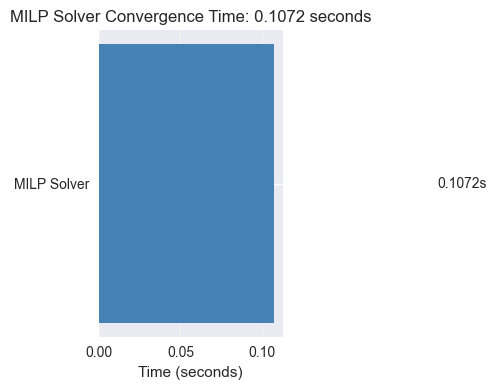

Disimpan: MILP_convergence_history_20260615_104116.csv

Ringkas (5 part pertama):
Part 1: DC1: Q=480, SS=7, ROP=22179
Disimpan: milp_best_solution.csv


In [56]:

# ========= Visualization & Export =========
# Plot convergence time (single solve)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(['MILP Solver'], [conv_sec], color='steelblue')
ax.set_xlabel('Time (seconds)')
ax.set_title(f'MILP Solver Convergence Time: {conv_sec:.4f} seconds')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate([conv_sec]):
    ax.text(v + 0.1, i, f'{v:.4f}s', va='center')
plt.tight_layout()
plt.show()

# Build convergence history (MILP solves once, so single row)
# Adding columns for consistency with GA/VNS notebooks: Step, Time_seconds, Total_cost, Holding, Ordering, Shortage, Order_miss_penalty
convergence_data = [{
    'Step': 1,
    'Time_seconds': conv_sec,
    'Total_cost': obj_val,
    'Holding': holding,
    'Ordering': ordering,
    'Shortage': shortage,
    'Order_miss_penalty': order_miss_penalty,
    'mean_cost': obj_val,  # For MILP, single solution so mean=best
}]

df_convergence = pd.DataFrame(convergence_data)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_convergence = f'MILP_convergence_history_{timestamp}.csv'
df_convergence.to_csv(csv_convergence, index=False)
print(f'Disimpan: {csv_convergence}')

# Ringkas & Ekspor
# Compute ROP
ROP_sol = D_dc * L_i.reshape(-1,1) + SS_sol

print('\nRingkas (5 part pertama):')
for i in range(min(5, M)):
    row_items=[]
    for jj,j in enumerate(DCs):
        row_items.append(f"DC{j}: Q={int(round(Q_sol[i,jj]))}, SS={int(round(SS_sol[i,jj]))}, ROP={int(round(ROP_sol[i,jj]))}")
    print(f"Part {i+1}: " + ' | '.join(row_items))

rows = []
for i in range(M):
    row = {
        'Part_id': int(raw.loc[i, 'Part_id']) if 'Part_id' in raw.columns and not pd.isna(raw.loc[i, 'Part_id']) else i+1,
        'Material': raw.loc[i, 'Material'],
        'Description': raw.loc[i, 'Material Description'],
        'Demand_total': float(D_tot[i]),
        'Lead_time_months': float(L_i[i]),
        'SS_target': float(SS_target[i]),
    }
    for jj, j in enumerate(DCs):
        row[f'Q_{j}']   = int(round(Q_sol[i, jj]))
        row[f'SS_{j}']  = int(round(SS_sol[i, jj]))
        row[f'ROP_{j}'] = float(ROP_sol[i, jj])
    rows.append(row)

pd.DataFrame(rows).to_csv('milp_best_solution.csv', index=False)
print('Disimpan: milp_best_solution.csv')